# Домашнє завдання: Інтерактивні візуалізації з Plotly

## Опис завдання
У цьому домашньому завданні ви будете створювати інтерактивні візуалізації з допомогою бібліотеки Plotly. Ви дізнаєтесь різницю між Plotly Express (швидкі графіки) та Graph Objects (повний контроль), та створите інтерактивний дашборд.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---

🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)


In [94]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

# Для plotly краще не встановлювати datetime як індекс
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.day_name()

# Додаємо назви кварталів в окрему колонку
quarter_map = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}
df['quarter_name'] = df['season'].map(quarter_map)

## Завдання 1: Базовий інтерактивний лінійний графік (Plotly Express)

**Завдання:**
Створіть інтерактивний лінійний графік динаміки оренди за часом (рівень деталізації - як в даних) з можливістю zoom та hover.

Дайте відповіді на питання.
**Питання для інтерпретації:**
1. Яка перевага інтерактивного графіка над статичним?
2. Чому на графіку є "пробіли" - ділянки, де одна пряма лінія зʼєднує два "суцільних" блоки з даними? Як би ви це могли дослідити на статичному графіку?


In [95]:
df.tail(2)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,weekday,quarter_name
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,12,22,Wednesday,Q4
10885,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88,12,23,Wednesday,Q4


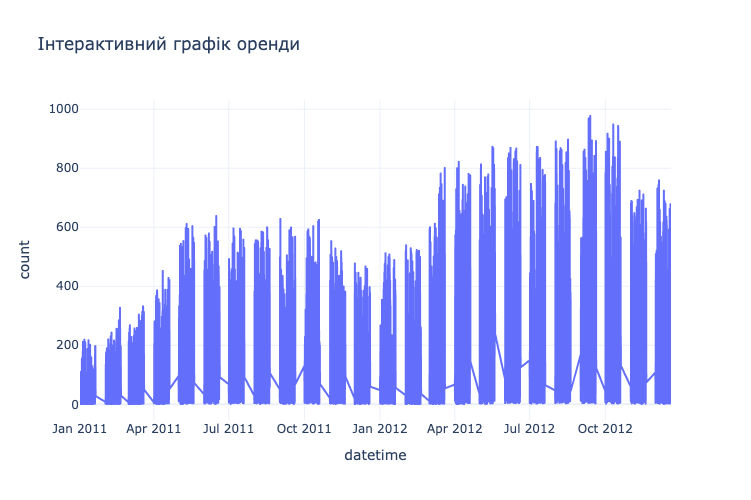

In [96]:
fig = px.line(df, x='datetime', y='count',
              title='Інтерактивний графік оренди')
fig.update_traces(line_width=2)
fig.update_layout(
    hovermode='x unified',
    template='plotly_white',
    height=500
)

1. Яка перевага інтерактивного графіка над статичним?
   Інтерактивний графік можна наблизити за необхідності, а також отримати більш детальну інформацію про кожну точку даних.
2. Чому на графіку є "пробіли" - ділянки, де одна пряма лінія зʼєднує два "суцільних" блоки з даними? Як би ви це могли дослідити на статичному графіку?
   В ці дні не було зафіксовано фактів оренди, в статичному графіку це були відрізки, паралельні ОХ (але там була агрегація у вигляді суми за день), а тут попередня точка даних зʼєднана із наступною лінією, але нульове значення відсутнє.

## Завдання 2: Scatter plot з додатковими даними (Plotly Express)

**Завдання:**
Створіть scatter plot кількості орендованих велосипедів випадковими користувачами vs кількості орендованих велосипедів зареєстрованими користувачами. Розмір точок встановіть за сумарною кількістю велосипедів, які були взяті в оренду, а колір - за сезоном(кварталом). В hover_data - додайте деталі, які допоможуть вам в подальшому аналізі.

Дослідіть графік. Зверніть увагу, що ви можете вмикати і вимикати окремі квартали, якщо будете клікати на колір кварталу в легенді графіку.

**Дайте відповідь на питання.**
- Як ви проінтерпретуєте роздвоєність цього графіку (дві явні лінії)? Що це означає?
- Які висновки для компанії, які дає велосипеди в оренду, ви можете зробити з цього графіку? 3 основних висновки.

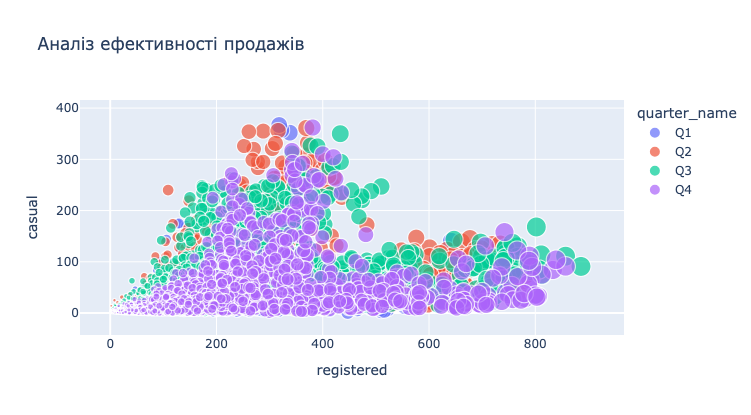

In [97]:
fig = px.scatter(df,
                 x='registered',
                 y='casual',
                 size='count',
                 color='quarter_name',
                 hover_data=['temp', 'weekday', 'count'],
                 title='Аналіз ефективності продажів',
                 labels={'conversion': 'Конверсія (%)'})
fig.update_layout(height=400, width=760)
fig.show()

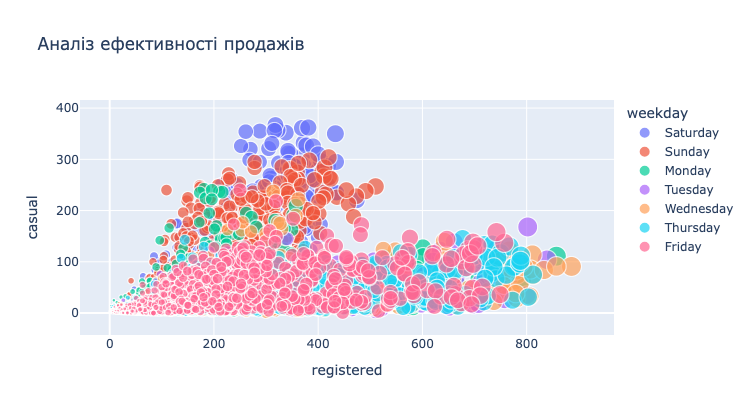

In [98]:
fig = px.scatter(df,
                 x='registered',
                 y='casual',
                 size='count',
                 color='weekday',
                 hover_data=['temp', 'weekday', 'count'],
                 title='Аналіз ефективності продажів',
                 labels={'conversion': 'Конверсія (%)'})
fig.update_layout(height=400, width=760)
fig.show()

1. Роздвоєність графіку (дві явні лінії) представляють собою два типи поведінки користувачів: у вихідні дні вона більше тяжіє до рівномірного розподілу між зареєстрованими та випадковими користувачами, а також зсувається в бік випадкових; а у робочі дні більш яскраво вираженим є тяжіння до великої кількості оренди від зареєстрованих користувачів.
2. Подібна нерівномірність дає потенційну можливість до зростання:
   - потрібно мотивувати випадкових користувачів реєструватися і тоді можливо вони будуть користуватися веловипедами як у вихідні, так і у робочі дні;
   - мотивувати зареєстрованих користувачів брати в оренду велосипеди і у вихідні, можливо запропонувати їх певну програму лояльності;
   - більш провальним відносно інших є 1й квартал, однак це пояснюється погодними умовами, які не сприяють велоруху. З інших графіків ми бачили, що оренда не працює в кінці кожного місяця, можливо корисніше буде працюватив цей період і працювати менше у 1-му кварталі.

## Завдання 3: Порівняння Plotly Express vs Graph Objects

**Завдання:**
Створіть лінійний графік помісячної динаміки оренди (кількість оренд) велосипедів двома способами - з Plotly Express та з Graph Objects.

**Дайте відповіді на питання.**
1. Як ви розумієте основну різницю між цими двома підходами?
2. Коли краще використовувати Plotly Express?
3. Коли потрібен Graph Objects?


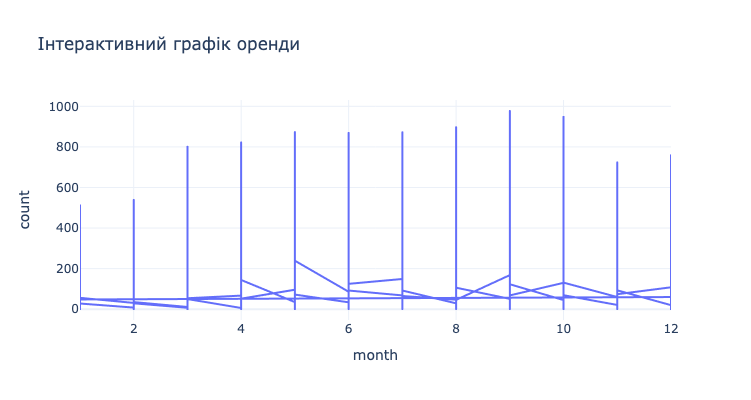

In [99]:
fig = px.line(df, x='month', y='count',
              title='Інтерактивний графік оренди')
fig.update_traces(line_width=2)
fig.update_layout(
    hovermode='x unified',
    template='plotly_white',
    height=400
)

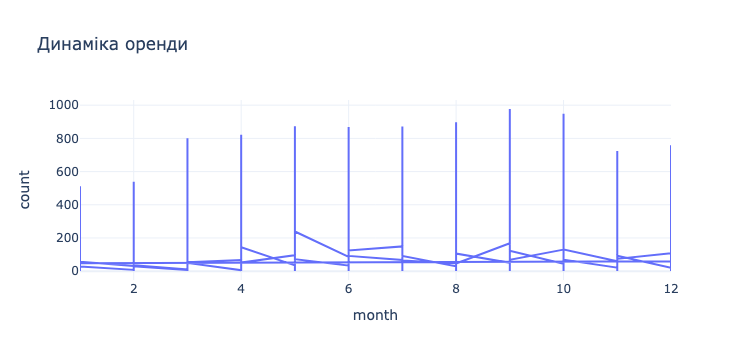

In [100]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df['month'],
        y=df['count'],
        mode='lines',
        hovertemplate='Місяць: %{x}<br>Оренда: %{y}<extra></extra>',
        name='count'
    )
)

fig.update_layout(
    title='Динаміка оренди',
    xaxis_title='month',
    yaxis_title='count',
    template='plotly_white'
)

fig.show()

1. Основна різниця між підходами px та go в задоволенні різних потреб: px - для швидкого створення одного графіку з мінімальною кількістю коду, тоді як go - використовується, якщо потрібно побудувати багато графіків та налаштовувати багато елементів не автоматичним чином.
2. Коли краще використовувати Plotly Express? Коли потрібно побудувати один графік
3. Коли потрібен Graph Objects? Коли потрібно декілька графіків з додатковими налаштуваннями елементів

## Завдання 4 (Опціональне): Дашборд з make_subplots (Graph Objects)

**Завдання:**
Створіть дашборд з 4 різними графіками в одній фігурі:
- Bar chart - середні значення загальної кількості оренд велосипедів за сезонами(кварталами)
- Pie chart - відсоткове співвідношення погодних умов в даних
- Line chart - середнє значення загальної кількості оренд велосипедів за годинами протягом доби
- Scatter plot - кореляція температури vs вологість

Додайте заголовок на дашборд.

**Дайте відповідь на питання**
- На ваш погляд, яка перевага об'єднання графіків в один дашборд?

In [101]:
quarter_mean = df.groupby('quarter_name')['count'].mean().reset_index()

In [120]:
hourly_mean = df.groupby('hour')['count'].mean().reset_index()

In [102]:
weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

In [103]:
df['weather_name'] = df['weather'].map(weather_labels)

In [110]:
weather_counts = df.groupby('weather_name')['count'].sum().reset_index()

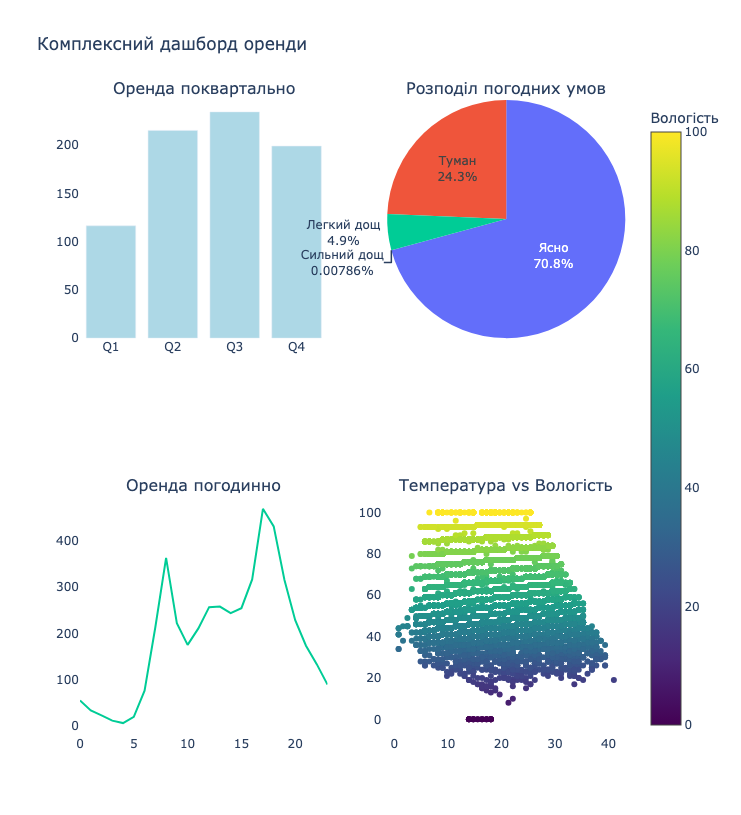

In [132]:
fig = make_subplots(
    rows=2, cols=2,
    specs=[
        [{"type": "xy"}, {"type": "domain"}],
        [{"type": "xy"}, {"type": "xy"}],
    ],
    subplot_titles=('Оренда поквартально', 'Розподіл погодних умов',
                    'Оренда погодинно', 'Температура vs Вологість')
)

fig.add_trace(
    go.Bar(
        x=quarter_mean['quarter_name'],
        y=quarter_mean['count'],
        marker=dict(color='lightblue'),
        hovertemplate='Квартал: %{x}<br>Оренда: %{y}<extra></extra>'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Pie(
        labels=weather_counts['weather_name'],
        values=weather_counts['count'],
        textinfo='label+percent',
        name=''
    ),
    row=1, col=2
)

fig.add_trace(
    go.Scatter(
        x=hourly_mean.index,
        y=hourly_mean['count'],
        mode='lines',
        hovertemplate='Hour: %{x}<br>Rents: %{y}<extra></extra>'
    ),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=df['temp'],
        y=df['humidity'],
        mode='markers',
        marker=dict(
            color=df['humidity'],
            colorscale='viridis',
            colorbar=dict(title='Вологість')
        ),
        hovertemplate=(
            'Температура: %{x}<br>'
            'Вологість: %{y}<extra></extra>'
        )
    ),
    row=2, col=2
)

fig.update_layout(
    height=800,
    width=800,
    showlegend=False,
    title_text="Комплексний дашборд оренди",
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()

Основною перевагою об'єднання графіків в один дашборд є наочність інформації, дані за різні періоди або ж різних категорій можуть бути представлені одночасно для розуміння та аналізу тенденцій та/або структури.

## Завдання 5 (Опціональне): 3D візуалізація

**Завдання:**
Створіть 3D scatter plot для аналізу взаємозв'язку температури, швидкості вітру та загальної кількості орендованих велосипедів. Колір встановіть за сезоном(кварталом), а розмір - за загальною кількість оренд також.

Дайте відповіді на питання.
**Питання для інтерпретації:**
1. Яку додаткову інформацію, на ваш погляд, дає 3D візуалізація?
2. Чи видно кластери в 3D просторі?
3. Чи ви можете зробити висновки з цієї візуалізації, чи вам було простіше побудувати кілька 2D?



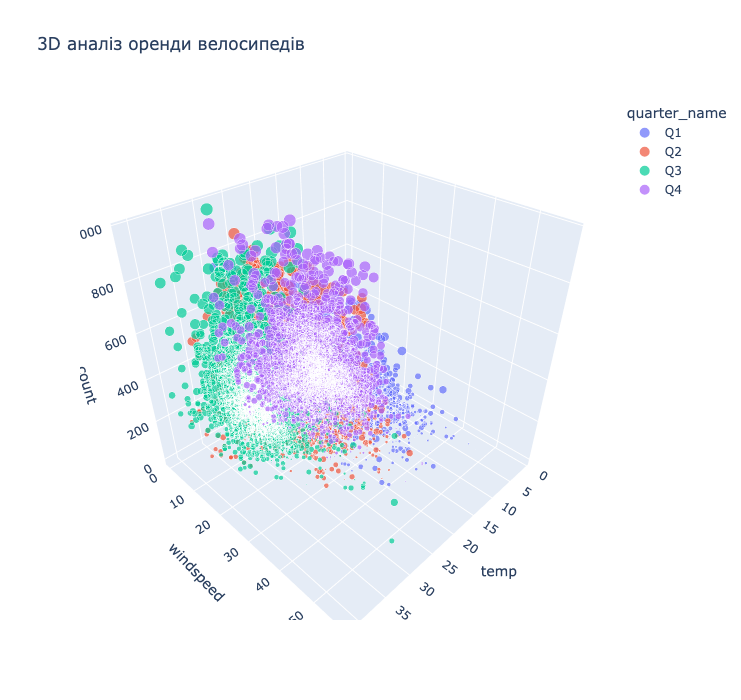

In [137]:
fig = px.scatter_3d(df.reset_index(),
                    x='temp', y='windspeed', z='count',
                    color='quarter_name', size='count',
                    title='3D аналіз оренди велосипедів')
fig.update_layout(height=700)
fig.show()

1. 3D візуалізація може представити певні дані більш наочно, однак в окремих випадках це не буде доречно. В даному графіку представлені 5 вимірів (x, y, z, колір та розмір), це досить багато для швидкого розуміння даних.
2. Чи видно кластери в 3D просторі? При малій вибірці даних не дуже видно (будувала спочатку на 100 значень), але при повній - так, якщо заглибитися у виміри, і почергово вмикати квартали, то можна зрозуміти, що відбувається.
3. Чи ви можете зробити висновки з цієї візуалізації, чи вам було простіше побудувати кілька 2D? Мені простіше зрозуміти графіки на площині. 


## Завдання 6: Експорт та збереження інтерактивних графіків

**Завдання:**
Збережіть побудований попередній графік на plotly в формат HTML. Також змініть вручну щось на графіку (зум, виділення частини графіку) і збережіть його як статичне зображення через іконку фотоапарату у формат PNG. Завантажте файли з графіком у HTML та PNG (або посилання на них на github) разом з посиланням на цей ноутбук при здачі ДЗ.


In [138]:
fig.write_html("dashboard_rents.html")